# Trabajo Práctico N.° 2 — Métodos no supervisados usando la EPH

**Taller de Programación — Universidad de Buenos Aires (2026)**  
**Grupo 7 — Lower-tier informal wage employees**  
**Integrantes:** Antony Araujo Guevara y Erick Huamanchumo Luis

Este notebook continúa el TP1 con las bases individuales de la EPH del cuarto trimestre de 2024 y 2025. Está organizado según los incisos del enunciado y genera tablas y figuras en carpetas listas para el informe.

> **Uso en Google Colab:** ejecutar las celdas en orden. Cuando se solicite, cargar simultáneamente `usu_individual_T424.xlsx` y `usu_individual_T425.xlsx`.


## 0. Preparación del entorno

In [1]:
# Instalación necesaria para k-modes (solo en Colab)
!pip -q install kmodes

In [2]:
from pathlib import Path
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from kmodes.kmodes import KModes

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

EN_COLAB = 'google.colab' in sys.modules
BASE = Path('/content/TP2_Grupo7') if EN_COLAB else Path.cwd() / 'TP2_Grupo7'
RAW = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'
FIG = BASE / 'resultados' / 'figuras'
TAB = BASE / 'resultados' / 'tablas'
for p in [RAW, PROC, FIG, TAB]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_theme(style='whitegrid')
print('Carpeta de trabajo:', BASE)

Carpeta de trabajo: /content/TP2_Grupo7


In [3]:
# Carga de archivos en Google Colab
esperados = {'usu_individual_T424.xlsx', 'usu_individual_T425.xlsx'}
existentes = {p.name for p in RAW.glob('*.xlsx')}
if EN_COLAB and not esperados.issubset(existentes):
    from google.colab import files
    print('Seleccione simultáneamente las dos bases EPH:')
    uploaded = files.upload()
    for nombre, contenido in uploaded.items():
        (RAW / Path(nombre).name).write_bytes(contenido)

FILES = {
    2024: RAW / 'usu_individual_T424.xlsx',
    2025: RAW / 'usu_individual_T425.xlsx'
}
for anio, ruta in FILES.items():
    if not ruta.exists():
        raise FileNotFoundError(f'No se encontró {ruta.name}')
print('Archivos encontrados correctamente.')

Seleccione simultáneamente las dos bases EPH:


Saving usu_individual_T424.xlsx to usu_individual_T424.xlsx
Saving usu_individual_T425.xlsx to usu_individual_T425.xlsx
Archivos encontrados correctamente.


## 1. Lectura, limpieza y continuidad con el TP1

Se conserva la definición del Grupo 7. Los ingresos de 2024 se expresan en pesos de diciembre de 2025 usando el mismo factor del TP1 (`1.315`).

In [4]:
ID_VARS = ['CODUSU','ANO4','TRIMESTRE','NRO_HOGAR','COMPONENTE','PONDERA']
VARS = [
    'CH04','CH06','CH07','CH08','CH12','CH13','CH14','NIVEL_ED',
    'ESTADO','CAT_OCUP','EMPLEO','SECTOR','PP04C','PP04C99','PP04B1',
    'PP04D_COD','PP04B_COD','PP04G','PP07H','PP3E_TOT','PP3F_TOT',
    'P21','P47T','REGION','AGLOMERADO'
]
KEEP = ID_VARS + VARS
FACTOR_2024_A_2025 = 1.315

def read_one(path, year):
    d = pd.read_excel(path, engine='openpyxl', usecols=lambda c: str(c).strip().upper() in KEEP)
    d.columns = [str(c).strip().upper() for c in d.columns]
    faltan = sorted(set(KEEP) - set(d.columns))
    if faltan:
        raise ValueError(f'Faltan columnas en {year}: {faltan}')
    for c in KEEP:
        if c != 'CODUSU':
            d[c] = pd.to_numeric(d[c], errors='coerce')
    d['CODUSU'] = d['CODUSU'].astype('string')
    d['ANIO'] = year
    return d

def clean(d):
    d = d.copy()
    especiales = {
        'CH07':[9], 'CH08':[9], 'NIVEL_ED':[9], 'CAT_OCUP':[9],
        'EMPLEO':[9], 'SECTOR':[9], 'PP04C':[99], 'PP04C99':[9],
        'PP07H':[0,9], 'PP04G':[0,99], 'PP04D_COD':[0,99999],
        'PP04B_COD':[0,99999], 'PP3E_TOT':[999], 'PP3F_TOT':[999],
        'CH12':[99], 'CH13':[9], 'CH14':[98,99]
    }
    for c, vals in especiales.items():
        d[c] = d[c].mask(d[c].isin(vals))
    for c in ['P21','P47T']:
        d[c] = d[c].mask(d[c] < 0)
    d['CH06'] = d['CH06'].mask((d['CH06'] < 0) | (d['CH06'] > 110))
    for c in ['PP3E_TOT','PP3F_TOT']:
        d[c] = d[c].mask((d[c] < 0) | (d[c] > 168))
    m24 = d['ANO4'].eq(2024)
    d.loc[m24, ['P21','P47T']] *= FACTOR_2024_A_2025
    d['mujer'] = np.where(d.CH04.eq(2), 1, np.where(d.CH04.eq(1), 0, np.nan))
    d['casado_unido'] = np.where(d.CH07.isin([1,2]), 1, np.where(d.CH07.notna(), 0, np.nan))
    d['educacion_superior'] = np.where(d.NIVEL_ED.isin([5,6]), 1, np.where(d.NIVEL_ED.notna(), 0, np.nan))
    d['ocupado'] = np.where(d.ESTADO.eq(1), 1, np.where(d.ESTADO.notna(), 0, np.nan))
    d['asalariado'] = np.where(d.CAT_OCUP.eq(3), 1, np.where(d.CAT_OCUP.notna(), 0, np.nan))
    d['sin_descuento_jubilatorio'] = np.where(d.PP07H.eq(2), 1, np.where(d.PP07H.eq(1), 0, np.nan))
    return d

base = pd.concat([clean(read_one(ruta, anio)) for anio, ruta in FILES.items()], ignore_index=True)
print('Dimensión de la base:', base.shape)
print(base.groupby('ANIO').size())

Dimensión de la base: (90563, 38)
ANIO
2024    46860
2025    43703
dtype: int64


## Parte I — Creación de variables y estadística descriptiva

### 1.a. Edad al cuadrado

In [5]:
base['edad'] = base['CH06']
base['edad2'] = base['edad'] ** 2

### 1.b. Años de educación (`educ`)

Criterio reproducible:

- Para niveles en curso o incompletos se suman los años aprobados (`CH14`) a los años acumulados antes del nivel.
- Para niveles completos (`CH13 = 1`) se utiliza al menos el total estándar del nivel.
- El ejemplo de la consigna se respeta: secundario, sexto año aprobado → 12 años.
- Educación especial y códigos sin respuesta quedan como faltantes.

Los acumulados usados son: primario/EGB = 0; secundario = 6; polimodal = 9; terciario/universitario = 12; posgrado = 17.

In [6]:
def crear_educ(df):
    nivel = df['CH12']
    completo = df['CH13']
    anio = df['CH14'].where(df['CH14'].between(0, 15))
    offset = nivel.map({1:0, 2:0, 3:0, 4:6, 5:9, 6:12, 7:12, 8:17})
    total_completo = nivel.map({1:0, 2:6, 3:9, 4:12, 5:12, 6:15, 7:17, 8:19})
    educ = offset + anio
    educ = np.where(completo.eq(1) & total_completo.notna(),
                    np.maximum(educ, total_completo), educ)
    educ = pd.Series(educ, index=df.index, dtype='float64')
    educ = educ.mask(nivel.eq(9) | nivel.isna())
    return educ.clip(lower=0, upper=25)

base['educ'] = crear_educ(base)
base[['CH12','CH13','CH14','educ']].sample(10, random_state=RANDOM_STATE)

,CH12,CH13,CH14,educ
53926,4.0,1.0,NaN,NaN
66233,6.0,2.0,2.0,14.0
37303,7.0,2.0,0.0,12.0
70903,6.0,1.0,NaN,NaN
22452,4.0,1.0,NaN,NaN
20821,4.0,1.0,NaN,NaN
58875,2.0,1.0,NaN,NaN
36940,6.0,2.0,1.0,13.0
22048,4.0,2.0,5.0,11.0
76178,4.0,1.0,NaN,NaN


### 1.c. Horas trabajadas

Se calcula para las personas ocupadas como suma de la ocupación principal y otras ocupaciones. Un faltante en una parte no se reemplaza automáticamente por cero, salvo que la otra parte esté observada y la faltante represente ausencia de horas según la estructura del cuestionario. Se incluye una variable específica para identificar al jefe del hogar (`COMPONENTE = 1`).

In [7]:
# En la EPH, los ceros observados se conservan. Si ambas partes faltan, el total queda faltante.
base['horastrabj'] = base[['PP3E_TOT','PP3F_TOT']].sum(axis=1, min_count=1)
base['horastrabj'] = base['horastrabj'].mask((base['horastrabj'] < 0) | (base['horastrabj'] > 168))
base['jefe_hogar'] = base['COMPONENTE'].eq(1).astype(int)
base['horastrab_jefe'] = base['horastrabj'].where(base['jefe_hogar'].eq(1))

### 1.d. Número de miembros del hogar

In [8]:
claves_hogar = ['ANIO','CODUSU','NRO_HOGAR']
base['nhogar'] = base.groupby(claves_hogar)['COMPONENTE'].transform('nunique')
base[claves_hogar + ['COMPONENTE','nhogar']].head(10)

,ANIO,CODUSU,NRO_HOGAR,COMPONENTE,nhogar
0,2024,TQRMNORTSHJKLMCDEHPJB00872828,1,2,2
1,2024,TQRMNOSRQHJLLNCDEHPJB00872829,1,1,2
2,2024,TQRMNOSRQHJLLNCDEHPJB00872829,1,2,2
3,2024,TQRMNOSQTHMKLQCDEHPJB00872830,1,1,2
4,2024,TQRMNOSQTHMKLQCDEHPJB00872830,1,2,2
5,2024,TQRMNOPYTHLMKOCDEIHJF00854747,1,1,5
6,2024,TQRMNOPYTHLMKOCDEIHJF00854747,1,2,5
7,2024,TQRMNOPYTHLMKOCDEIHJF00854747,1,3,5
8,2024,TQRMNOPYTHLMKOCDEIHJF00854747,1,4,5
9,2024,TQRMNOPYTHLMKOCDEIHJF00854747,1,5,5


### Reconstrucción de la muestra ocupada y del indicador de informalidad lower-tier

In [9]:
respondieron = base[base['ESTADO'].ne(0) & base['ESTADO'].notna()].copy()
ocupados = respondieron[respondieron['ESTADO'].eq(1)].copy()
wa = ocupados[ocupados['CAT_OCUP'].eq(3)].copy()

pequeno = (
    wa['PP04C'].between(1,5)
    | (wa['PP04C'].isna() & wa['PP04C99'].eq(1))
    | wa['PP04B1'].eq(1)
    | wa['SECTOR'].eq(3)
)
largo = wa['PP04C'].between(6,12) | (wa['PP04C'].isna() & wa['PP04C99'].isin([2,3]))
wa['estatus_laboral'] = np.select(
    [wa.PP07H.eq(1), wa.PP07H.eq(2) & pequeno, wa.PP07H.eq(2) & largo],
    ['Formal asalariado','Informal lower-tier','Informal upper-tier'],
    default='No clasificable'
)
wa['informal'] = np.where(wa['estatus_laboral'].eq('Informal lower-tier'), 1,
                 np.where(wa['estatus_laboral'].eq('Formal asalariado'), 0, np.nan))
# Muestra binaria comparable: formal vs. informal lower-tier
analitica = wa[wa['informal'].notna()].copy()
analitica['informal'] = analitica['informal'].astype(int)
print(pd.crosstab(analitica.ANIO, analitica.estatus_laboral, margins=True))

estatus_laboral  Formal asalariado  Informal lower-tier    All
ANIO                                                          
2024                          9727                 3241  12968
2025                          8815                 2953  11768
All                          18542                 6194  24736


### 2. Estadística descriptiva

In [10]:
variables_desc = [
    'CH06','edad2','educ','horastrabj','nhogar','P21','P47T','PP04C',
    'mujer','casado_unido','educacion_superior','sin_descuento_jubilatorio'
]

def descriptivas(df, vars_):
    return df[vars_].describe(percentiles=[.25,.5,.75]).T.rename(columns={
        'count':'observaciones','mean':'promedio','std':'sd','min':'min',
        '25%':'p25','50%':'p50','75%':'p75','max':'max'
    })[['observaciones','promedio','sd','min','p25','p50','p75','max']]

tabla_desc = pd.concat(
    {anio: descriptivas(base[base.ANIO.eq(anio)], variables_desc) for anio in [2024,2025]},
    names=['anio','variable']
).round(2)
display(tabla_desc)
tabla_desc.to_csv(TAB / 'tabla_descriptiva_2024_2025.csv')

observaciones   promedio         sd  min  \
anio variable                                                              
2024 CH06                             46554.0      37.01      22.04  1.0   
     edad2                            46554.0    1855.37    1856.53  1.0   
     educ                             22411.0       8.01       4.72  0.0   
     horastrabj                       21119.0      37.25      16.73  0.0   
     nhogar                           46860.0       3.79       1.92  1.0   
     P21                              42585.0  327820.77  649640.43  0.0   
     P47T                             40900.0  492135.58  734639.81  0.0   
     PP04C                            18423.0       4.99       3.79  0.0   
     mujer                            46860.0       0.52       0.50  0.0   
     casado_unido                     46859.0       0.38       0.48  0.0   
     educacion_superior               46860.0       0.27       0.44  0.0   
     sin_descuento_jubilatorio        15292.0       0.36       0.48  0.0   
2025 CH06                             43456.0      37.81      22.20  1.0   
     edad2                            43456.0    1922.05    1897.70  1.0   
     educ                             20476.0       8.06       4.69  0.0   
     horastrabj                       19689.0      37.43      16.88  0.0   
     nhogar                           43703.0       3.75       1.87  1.0   
     P21                              39789.0  363850.00  727481.68  0.0   
     P47T                             38084.0  544200.38  843555.13  0.0   
     PP04C                            17004.0       4.80       3.78  0.0   
     mujer                            43703.0       0.53       0.50  0.0   
     casado_unido                     43700.0       0.38       0.48  0.0   
     educacion_superior               43703.0       0.27       0.44  0.0   
     sin_descuento_jubilatorio        13943.0       0.37       0.48  0.0   

                                  p25       p50       p75         max  
anio variable                                                          
2024 CH06                        19.0      35.0      54.0       103.0  
     edad2                      361.0    1225.0    2916.0     10609.0  
     educ                         4.0       8.0      12.0        22.0  
     horastrabj                  25.0      40.0      48.0       154.0  
     nhogar                       2.0       4.0       5.0        19.0  
     P21                          0.0       0.0  499700.0  19725000.0  
     P47T                         0.0  315600.0  715763.7  21697500.0  
     PP04C                        1.0       5.0       8.0        12.0  
     mujer                        0.0       1.0       1.0         1.0  
     casado_unido                 0.0       0.0       1.0         1.0  
     educacion_superior           0.0       0.0       1.0         1.0  
     sin_descuento_jubilatorio    0.0       0.0       1.0         1.0  
2025 CH06                        19.0      36.0      55.0       101.0  
     edad2                      361.0    1296.0    3025.0     10201.0  
     educ                         4.0       8.0      12.0        21.0  
     horastrabj                  25.0      40.0      48.0       168.0  
     nhogar                       2.0       4.0       5.0        16.0  
     P21                          0.0       0.0  600000.0  30000000.0  
     P47T                         0.0  350000.0  800000.0  30000000.0  
     PP04C                        1.0       4.0       8.0        12.0  
     mujer                        0.0       1.0       1.0         1.0  
     casado_unido                 0.0       0.0       1.0         1.0  
     educacion_superior           0.0       0.0       1.0         1.0  
     sin_descuento_jubilatorio    0.0       0.0       1.0         1.0

**Guía para comentar:** comparar nivel y dispersión entre años; señalar la asimetría de ingresos (media por encima de mediana), la relación mecánica entre edad y edad² y cualquier valor extremo en horas, ingreso o tamaño del establecimiento.

### 3. Matrices de correlación 2024 y 2025

Se utiliza correlación de Pearson con eliminación por pares. `informal` es binaria, por lo que su correlación con variables continuas equivale a una correlación punto-biserial. La interpretación es descriptiva y no causal.

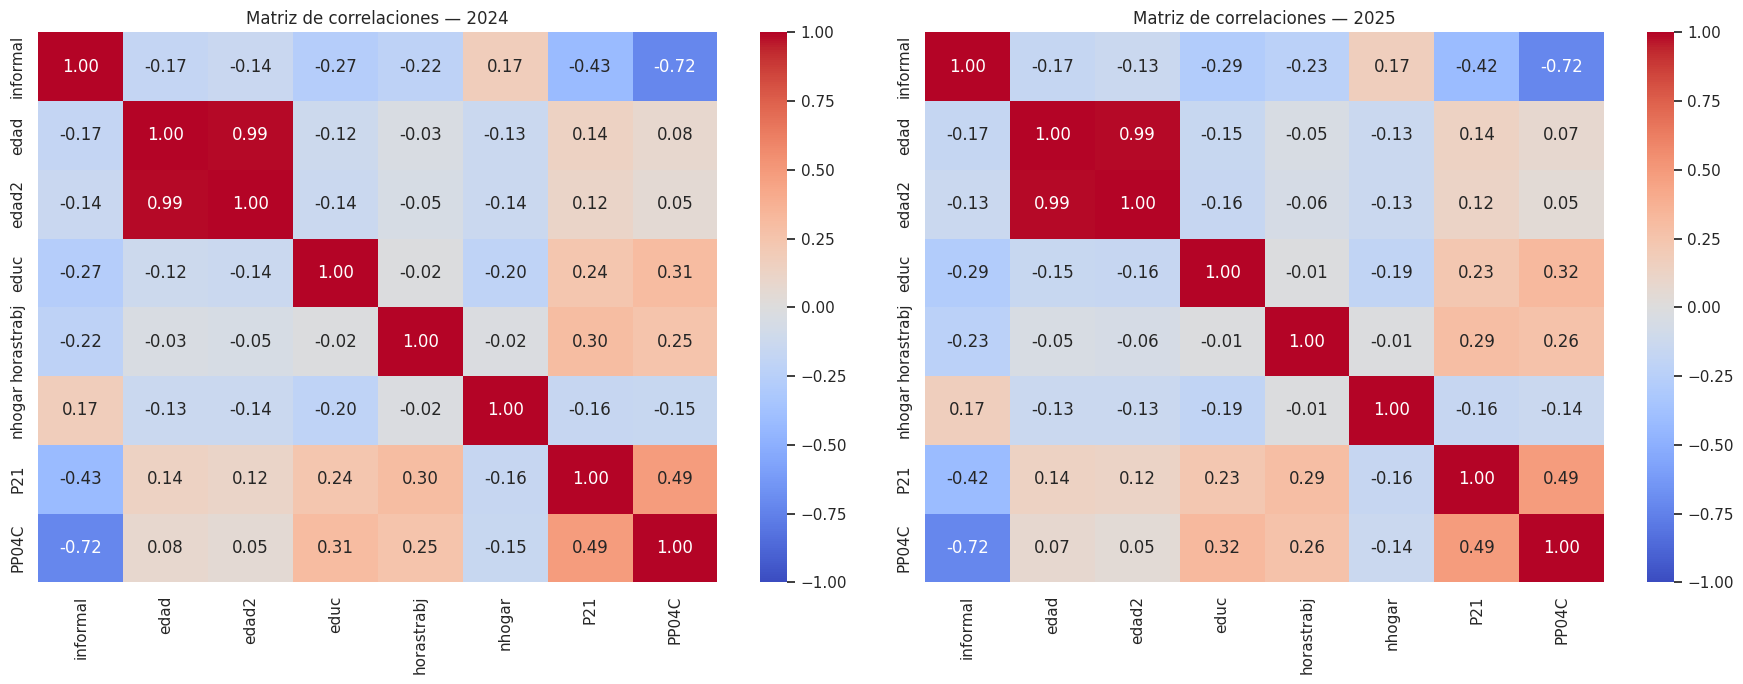

,corr_2024,corr_2025,cambio_abs
edad,-0.175,-0.168,0.007
edad2,-0.141,-0.133,0.007
educ,-0.270,-0.285,0.015
horastrabj,-0.217,-0.233,0.016
nhogar,0.172,0.168,0.004
P21,-0.426,-0.416,0.010
PP04C,-0.720,-0.719,0.002


In [11]:
vars_corr = ['informal','edad','edad2','educ','horastrabj','nhogar','P21','PP04C']
corrs = {}
fig, axes = plt.subplots(1,2, figsize=(18,7))
for ax, anio in zip(axes, [2024,2025]):
    c = analitica.loc[analitica.ANIO.eq(anio), vars_corr].corr()
    corrs[anio] = c
    sns.heatmap(c, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Matriz de correlaciones — {anio}')
plt.tight_layout()
plt.savefig(FIG / 'correlaciones_2024_2025.png', dpi=300, bbox_inches='tight')
plt.show()

comparacion = pd.DataFrame({
    'corr_2024': corrs[2024]['informal'].drop('informal'),
    'corr_2025': corrs[2025]['informal'].drop('informal')
})
comparacion['cambio_abs'] = (comparacion.corr_2025 - comparacion.corr_2024).abs()
display(comparacion.round(3))
comparacion.to_csv(TAB / 'comparacion_correlaciones_informalidad.csv')

In [ ]:
def nivel_correlacion(x):
    a = abs(x)
    return 'baja' if a < .30 else ('mediana' if a < .60 else 'alta')
for anio in [2024,2025]:
    s = corrs[anio]['informal'].drop('informal')
    print(anio, 'máxima correlación absoluta con informalidad:', round(s.abs().max(),3),
          '=>', nivel_correlacion(s.abs().max()))

## Parte II — Métodos no supervisados

Para PCA y clustering numérico se usan observaciones completas de la muestra binaria formal versus informal lower-tier. Las variables se estandarizan porque están medidas en escalas muy diferentes. No se incluye `informal` entre los predictores.

In [12]:
vars_modelo = ['edad','edad2','educ','horastrabj','nhogar','P21','PP04C']
modelo = analitica.dropna(subset=vars_modelo + ['informal']).copy()
# Se conserva el ingreso armonizado del TP1 y se evita truncar outliers para poder detectarlos.
X = modelo[vars_modelo]
y = modelo['informal'].to_numpy()
scaler = StandardScaler()
Xz = scaler.fit_transform(X)
print('Observaciones completas para modelado:', len(modelo))
print('Proporción informal:', round(modelo.informal.mean(), 3))

Observaciones completas para modelado: 5508
Proporción informal: 0.378


### A.1. PCA: scores del primer y segundo componente

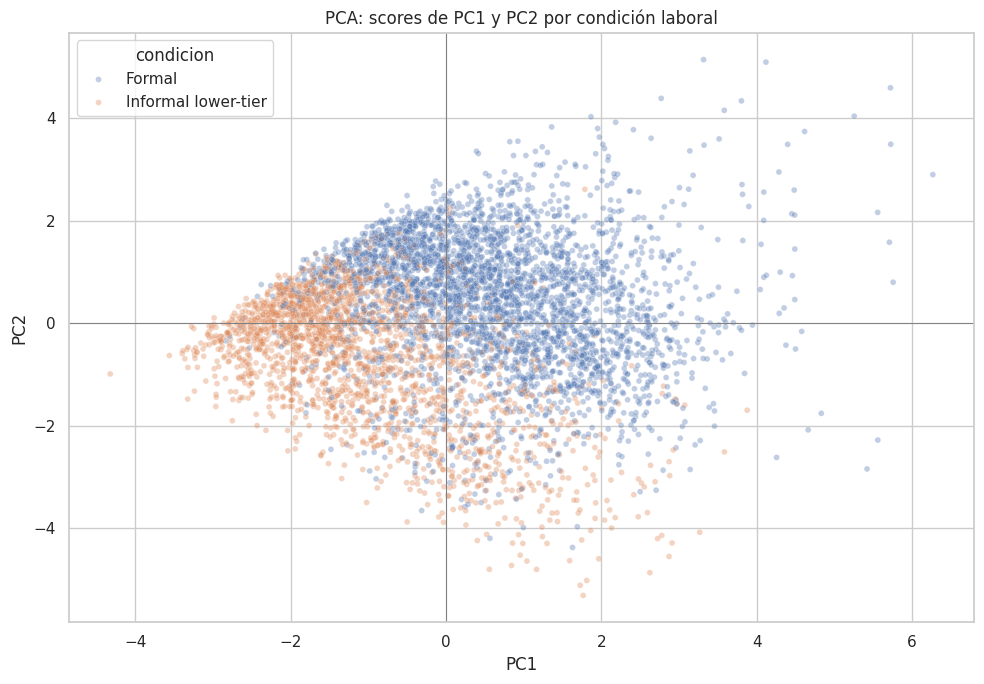

,ANIO,CODUSU,COMPONENTE,condicion,edad,edad2,educ,horastrabj,nhogar,P21,PP04C,PC1,PC2
537,2024,TQRMNOSSUHLKKQCDEIIAD00872617,1,Formal,43.0,1849.0,18.0,45.0,1,4339500.0,12.0,3.514136,3.596121
3322,2024,TQRMNOQSWHMKKOCDEIJAH00812368,2,Informal lower-tier,76.0,5776.0,5.0,5.0,5,65750.0,0.0,1.764209,-5.315121
4455,2024,TQRMNOQPPHKMLQCDEFMDB00870122,2,Formal,62.0,3844.0,15.0,40.0,2,5260000.0,12.0,5.555615,2.161975
4959,2024,TQRMNORWSHMNLNCDEHGHJ00810735,1,Formal,44.0,1936.0,8.0,84.0,4,6575000.0,7.0,4.397241,3.490009
4972,2024,TQRMNORRVHMLMOCDEIJAH00869038,1,Formal,78.0,6084.0,14.0,40.0,1,986250.0,11.0,4.829882,-1.760196
5662,2024,TQRMNOPSPHMNOTCDEIJAH00812245,2,Formal,57.0,3249.0,8.0,45.0,4,9205000.0,4.0,6.266484,2.899358
10910,2024,TQRMNOQWYHKOKNCDEGNFJ00869378,1,Formal,52.0,2704.0,18.0,70.0,3,5917500.0,11.0,5.253788,4.041228
13622,2024,TQRMNOQSXHLMKRCDEFPCH00852516,1,Formal,47.0,2209.0,9.0,60.0,2,5260000.0,12.0,4.284103,2.949888
18761,2024,TQRMNORPWHLMLNCDEHGHJ00853683,1,Formal,28.0,784.0,13.0,72.0,3,5917500.0,12.0,3.314131,5.143796
21626,2024,TQRMNOQSWHMMLMCDEFPCH00809583,1,Formal,43.0,1849.0,19.0,72.0,5,4997000.0,12.0,3.801976,4.338744


In [13]:
pca = PCA(n_components=len(vars_modelo), random_state=RANDOM_STATE)
scores = pca.fit_transform(Xz)
modelo['PC1'] = scores[:,0]
modelo['PC2'] = scores[:,1]
modelo['condicion'] = modelo['informal'].map({0:'Formal',1:'Informal lower-tier'})

plt.figure(figsize=(10,7))
sns.scatterplot(data=modelo, x='PC1', y='PC2', hue='condicion', alpha=.35, s=18)
plt.axhline(0, color='gray', lw=.7); plt.axvline(0, color='gray', lw=.7)
plt.title('PCA: scores de PC1 y PC2 por condición laboral')
plt.tight_layout(); plt.savefig(FIG/'pca_scores.png', dpi=300, bbox_inches='tight'); plt.show()

# Outliers multivariados simples: distancia en el plano PC1-PC2 sobre percentil 99.5
modelo['dist_pc12'] = np.sqrt(modelo.PC1**2 + modelo.PC2**2)
umbral = modelo.dist_pc12.quantile(.995)
outliers = modelo[modelo.dist_pc12.gt(umbral)][['ANIO','CODUSU','COMPONENTE','condicion']+vars_modelo+['PC1','PC2']]
display(outliers.head(20))
outliers.to_csv(TAB/'outliers_pca.csv', index=False)

### A.2. Loadings y biplot

,PC1,PC2
edad,0.541,-0.417
edad2,0.528,-0.436
educ,0.083,0.435
horastrabj,0.242,0.297
nhogar,-0.244,-0.107
P21,0.419,0.387
PP04C,0.359,0.445


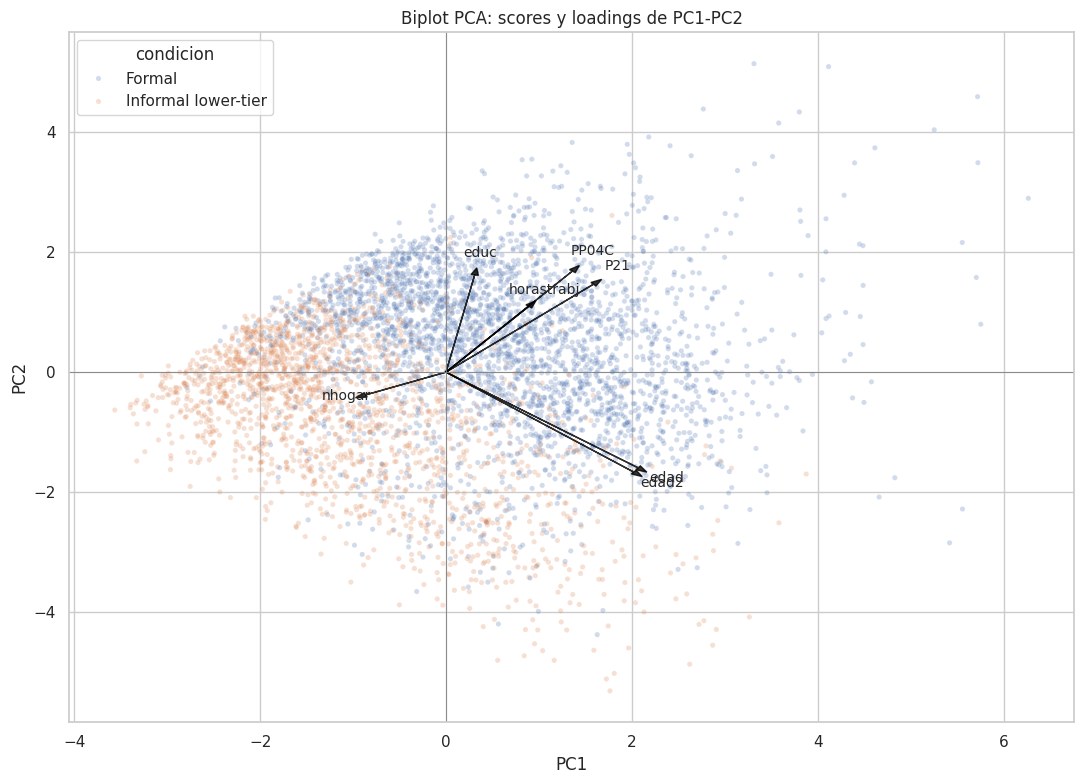

In [14]:
loadings = pd.DataFrame(pca.components_.T, index=vars_modelo,
                        columns=[f'PC{i}' for i in range(1,len(vars_modelo)+1)])
display(loadings[['PC1','PC2']].round(3))
loadings.to_csv(TAB/'pca_loadings.csv')

plt.figure(figsize=(11,8))
# Muestra para legibilidad del biplot
plot_df = modelo.sample(min(5000, len(modelo)), random_state=RANDOM_STATE)
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='condicion', alpha=.25, s=14)
escala = 4.0
for var in vars_modelo:
    x, yy = loadings.loc[var, ['PC1','PC2']] * escala
    plt.arrow(0,0,x,yy,color='black',alpha=.8,head_width=.08,length_includes_head=True)
    plt.text(x*1.10, yy*1.10, var, fontsize=10, ha='center')
plt.axhline(0,color='gray',lw=.6); plt.axvline(0,color='gray',lw=.6)
plt.title('Biplot PCA: scores y loadings de PC1-PC2')
plt.tight_layout(); plt.savefig(FIG/'pca_biplot.png', dpi=300, bbox_inches='tight'); plt.show()

### A.3. Proporción de varianza explicada

,componente,proporcion,acumulada
0,1,0.3146,0.3146
1,2,0.2690,0.5836
2,3,0.1573,0.7409
3,4,0.1136,0.8545
4,5,0.0802,0.9347
5,6,0.0634,0.9981
6,7,0.0019,1.0000


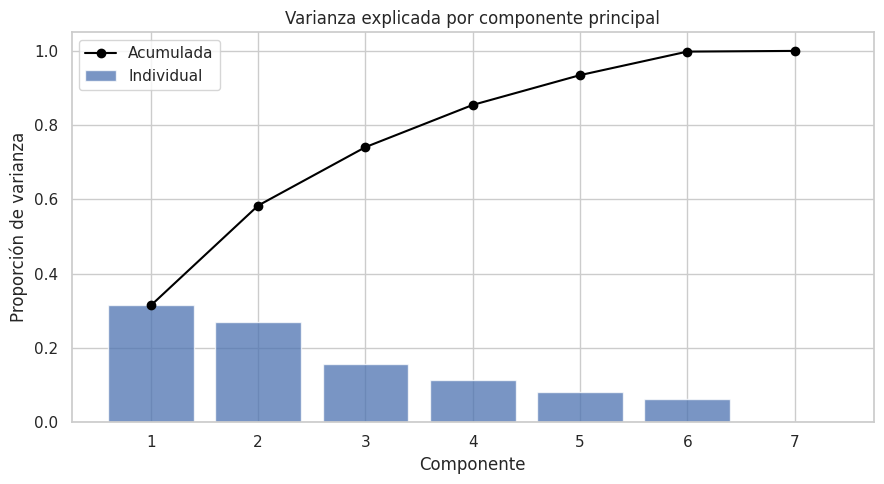

In [15]:
var_exp = pd.DataFrame({
    'componente': np.arange(1,len(vars_modelo)+1),
    'proporcion': pca.explained_variance_ratio_,
    'acumulada': np.cumsum(pca.explained_variance_ratio_)
})
display(var_exp.round(4))
plt.figure(figsize=(9,5))
plt.bar(var_exp.componente, var_exp.proporcion, alpha=.75, label='Individual')
plt.plot(var_exp.componente, var_exp.acumulada, marker='o', color='black', label='Acumulada')
plt.xticks(var_exp.componente); plt.ylim(0,1.05)
plt.xlabel('Componente'); plt.ylabel('Proporción de varianza')
plt.title('Varianza explicada por componente principal'); plt.legend()
plt.tight_layout(); plt.savefig(FIG/'pca_varianza_explicada.png', dpi=300, bbox_inches='tight'); plt.show()

### B.4.a. K-means con k = 2

informal,0,1
cluster_k2,,
0,1592,1587
1,1833,496


ARI (invariante a etiquetas): 0.057
Coincidencia tras alinear etiquetas: 0.622


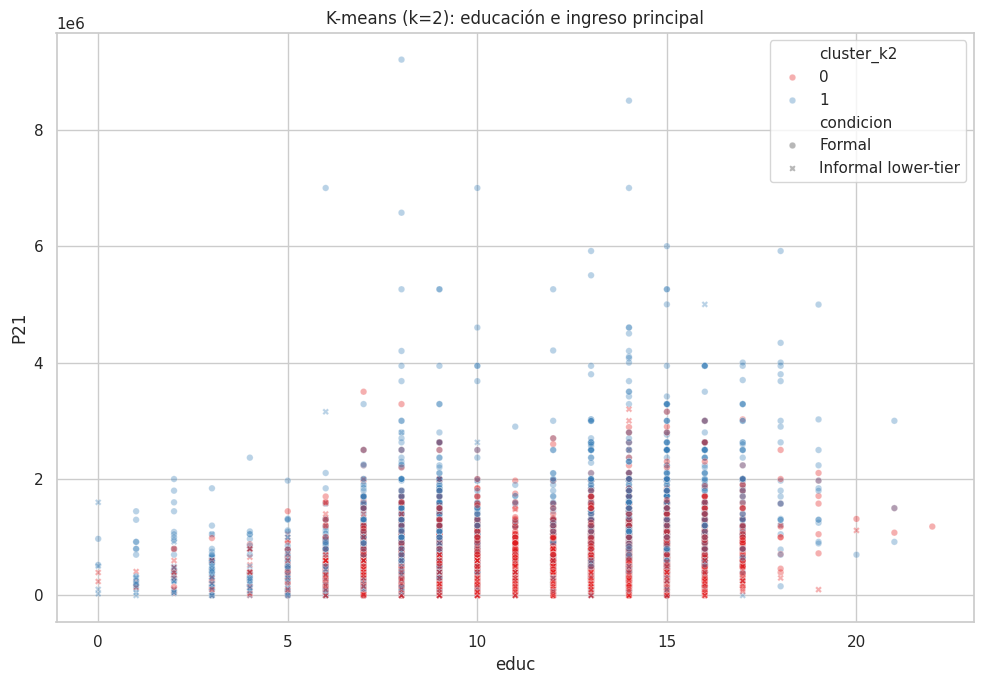

In [16]:
kmeans2 = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
modelo['cluster_k2'] = kmeans2.fit_predict(Xz)

# La etiqueta numérica del cluster es arbitraria; se alinea solo para calcular exactitud descriptiva.
tabla_k2 = pd.crosstab(modelo.cluster_k2, modelo.informal)
display(tabla_k2)
mapa = tabla_k2.idxmax(axis=1).to_dict()
pred_alineada = modelo.cluster_k2.map(mapa).to_numpy()
print('ARI (invariante a etiquetas):', round(adjusted_rand_score(y, modelo.cluster_k2),3))
print('Coincidencia tras alinear etiquetas:', round((pred_alineada == y).mean(),3))

# Visualización usando educ e ingreso (dos de las siete variables)
plt.figure(figsize=(10,7))
sns.scatterplot(data=modelo, x='educ', y='P21', hue='cluster_k2', style='condicion', alpha=.35, s=22,
                palette='Set1')
plt.title('K-means (k=2): educación e ingreso principal')
plt.tight_layout(); plt.savefig(FIG/'kmeans_k2_educ_ingreso.png', dpi=300, bbox_inches='tight'); plt.show()

### B.4.b. Método del codo para k = 1,...,40

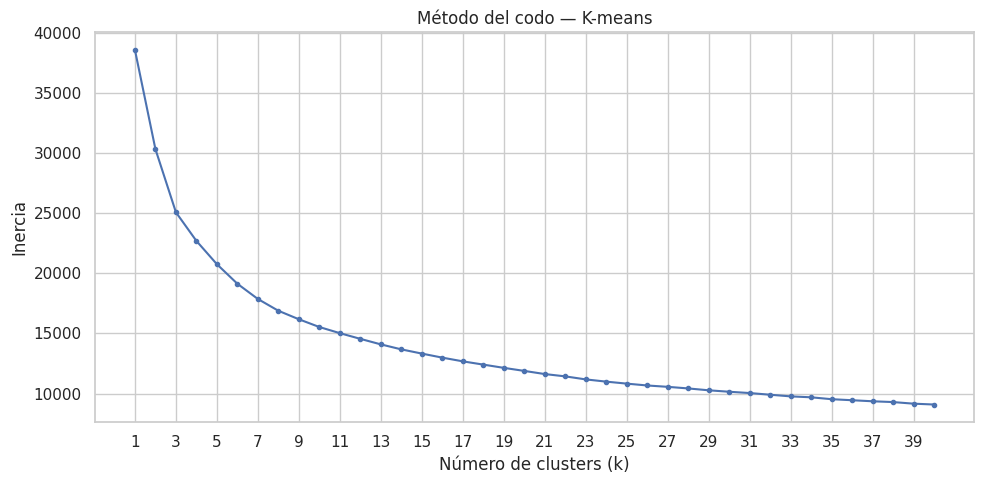

In [17]:
inercias = []
for k in range(1,41):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    km.fit(Xz)
    inercias.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,41), inercias, marker='o', ms=3)
plt.xticks(range(1,41,2)); plt.xlabel('Número de clusters (k)'); plt.ylabel('Inercia')
plt.title('Método del codo — K-means')
plt.tight_layout(); plt.savefig(FIG/'kmeans_elbow.png', dpi=300, bbox_inches='tight'); plt.show()
pd.DataFrame({'k':range(1,41),'inercia':inercias}).to_csv(TAB/'kmeans_elbow.csv', index=False)

### B.5. Clustering jerárquico

Un dendrograma representa el proceso de fusiones sucesivas entre observaciones o grupos. La altura de cada unión indica la disimilitud a la que dos ramas se combinan. Por el costo cuadrático en memoria, se utiliza una muestra aleatoria reproducible de hasta 1.500 observaciones. El método Ward se aplica sobre variables estandarizadas.

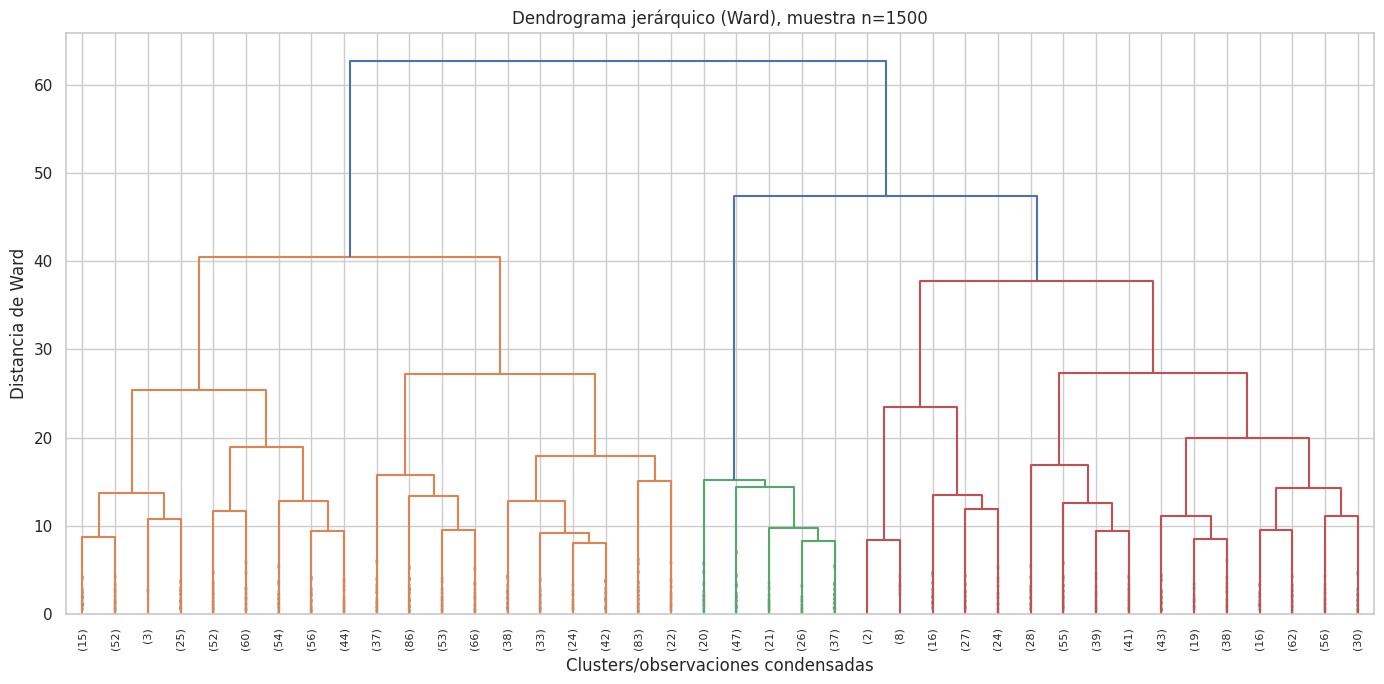

ARI jerárquico k=2 vs informalidad: 0.058


informal,0,1
cluster,,
1,420,425
2,508,147


In [18]:
n_h = min(1500, len(modelo))
idx_h = modelo.sample(n_h, random_state=RANDOM_STATE).index
pos_h = modelo.index.get_indexer(idx_h)
Xh = Xz[pos_h]
Zh = linkage(Xh, method='ward')

plt.figure(figsize=(14,7))
dendrogram(Zh, truncate_mode='lastp', p=40, leaf_rotation=90, leaf_font_size=8,
           show_contracted=True)
plt.title(f'Dendrograma jerárquico (Ward), muestra n={n_h}')
plt.xlabel('Clusters/observaciones condensadas'); plt.ylabel('Distancia de Ward')
plt.tight_layout(); plt.savefig(FIG/'dendrograma_ward.png', dpi=300, bbox_inches='tight'); plt.show()

cl_h2 = fcluster(Zh, t=2, criterion='maxclust')
yh = modelo.loc[idx_h, 'informal'].to_numpy()
print('ARI jerárquico k=2 vs informalidad:', round(adjusted_rand_score(yh, cl_h2),3))
display(pd.crosstab(cl_h2, yh, rownames=['cluster'], colnames=['informal']))

### B.6. K-modes

Se usan las dummies del TP1 y las nuevas variables numéricas categorizadas. Se excluye `sin_descuento_jubilatorio` porque forma parte directa de la definición del objetivo y produciría fuga de información. También se eliminan columnas constantes. `informal` no entra al algoritmo y solo se usa después para evaluar la correspondencia.

In [19]:
km_df = analitica.copy()
# Categorización reproducible
km_df['edad_cat'] = pd.cut(km_df.edad, bins=[0,24,34,44,54,64,200], labels=False, include_lowest=True)
km_df['educ_cat'] = pd.cut(km_df.educ, bins=[-1,6,9,12,16,25], labels=False)
km_df['horas_cat'] = pd.cut(km_df.horastrabj, bins=[-1,20,35,48,60,168], labels=False)
km_df['nhogar_cat'] = pd.cut(km_df.nhogar, bins=[0,1,2,4,6,np.inf], labels=False)
km_df['ingreso_cat'] = km_df.groupby('ANIO')['P21'].transform(
    lambda s: pd.qcut(s.rank(method='first'), q=4, labels=False, duplicates='drop'))
km_df['tam_est_cat'] = pd.cut(km_df.PP04C, bins=[0,1,5,10,40,200,np.inf], labels=False)

vars_km = ['mujer','casado_unido','educacion_superior',
           'edad_cat','educ_cat','horas_cat','nhogar_cat','ingreso_cat','tam_est_cat']
km_complete = km_df.dropna(subset=vars_km + ['informal']).copy()
Xkm = km_complete[vars_km].astype(int).astype(str)
# Quitar variables sin variación
Xkm = Xkm.loc[:, Xkm.nunique() > 1]
ykm = km_complete.informal.to_numpy()
print('Variables k-modes:', Xkm.columns.tolist())
print('Observaciones:', len(Xkm))

Variables k-modes: ['mujer', 'casado_unido', 'educacion_superior', 'edad_cat', 'educ_cat', 'horas_cat', 'nhogar_cat', 'ingreso_cat', 'tam_est_cat']
Observaciones: 4633


In [20]:
kmodes2 = KModes(n_clusters=2, init='Huang', n_init=20, random_state=RANDOM_STATE, verbose=0)
cl_km2 = kmodes2.fit_predict(Xkm)
print('Costo k=2:', kmodes2.cost_)
print('ARI k-modes k=2 vs informalidad:', round(adjusted_rand_score(ykm, cl_km2),3))
display(pd.crosstab(cl_km2, ykm, rownames=['cluster'], colnames=['informal']))
centros_km = pd.DataFrame(kmodes2.cluster_centroids_, columns=Xkm.columns)
display(centros_km)
centros_km.to_csv(TAB/'kmodes_centroides_k2.csv', index=False)

Costo k=2: 18469.0
ARI k-modes k=2 vs informalidad: 0.207


informal,0,1
cluster,,
0,1170,1301
1,2070,92


,mujer,casado_unido,educacion_superior,edad_cat,educ_cat,horas_cat,nhogar_cat,ingreso_cat,tam_est_cat
0,0,0,0,1,1,2,2,0,1
1,0,1,1,2,3,2,2,3,2


### B.6.b. Método del codo para K-modes

Se evalúa `k = 1,...,15`; el costo es la suma de disimilitudes categóricas respecto de las modas de cada cluster.

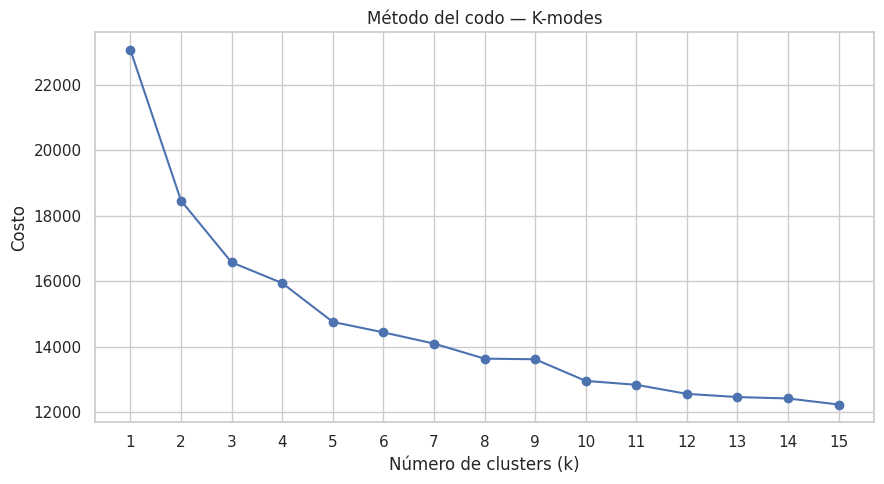

In [21]:
costos = []
for k in range(1,16):
    km = KModes(n_clusters=k, init='Huang', n_init=10, random_state=RANDOM_STATE, verbose=0)
    km.fit(Xkm)
    costos.append(km.cost_)
plt.figure(figsize=(9,5))
plt.plot(range(1,16), costos, marker='o')
plt.xticks(range(1,16)); plt.xlabel('Número de clusters (k)'); plt.ylabel('Costo')
plt.title('Método del codo — K-modes')
plt.tight_layout(); plt.savefig(FIG/'kmodes_elbow.png', dpi=300, bbox_inches='tight'); plt.show()
pd.DataFrame({'k':range(1,16),'costo':costos}).to_csv(TAB/'kmodes_elbow.csv', index=False)

## Exportación final

La siguiente celda guarda las bases procesadas y, en Colab, genera un ZIP con tablas, figuras y bases. El notebook debe descargarse desde **Archivo → Descargar → Descargar .ipynb**.

In [22]:
base.to_csv(PROC/'base_tp2.csv.gz', index=False, compression='gzip')
analitica.to_csv(PROC/'muestra_analitica_formal_lower_tier.csv.gz', index=False, compression='gzip')

# Resumen automático útil para redactar el informe
resumen_final = {
    'n_base': int(len(base)),
    'n_ocupados': int(len(ocupados)),
    'n_analitica': int(len(analitica)),
    'n_modelo_completo': int(len(modelo)),
    'varianza_PC1': float(pca.explained_variance_ratio_[0]),
    'varianza_PC2': float(pca.explained_variance_ratio_[1]),
    'ARI_kmeans_k2': float(adjusted_rand_score(y, modelo.cluster_k2)),
    'ARI_kmodes_k2': float(adjusted_rand_score(ykm, cl_km2))
}
with open(TAB/'resumen_modelos.json','w',encoding='utf-8') as f:
    json.dump(resumen_final, f, ensure_ascii=False, indent=2)
print(json.dumps(resumen_final, indent=2))

if EN_COLAB:
    import shutil
    zip_path = shutil.make_archive('/content/TP2_Grupo7_resultados', 'zip', BASE)
    from google.colab import files
    files.download(zip_path)

{
  "n_base": 90563,
  "n_ocupados": 40830,
  "n_analitica": 24736,
  "n_modelo_completo": 5508,
  "varianza_PC1": 0.31457110613134764,
  "varianza_PC2": 0.2690323836104915,
  "ARI_kmeans_k2": 0.05699138185865265,
  "ARI_kmodes_k2": 0.20651410591475358
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>